## importing necessary libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib

### convert data to pandas datafarme and read data

In [2]:
df = pd.read_csv("RTA Dataset.csv")

| English Column                        | Arabic Translation                           |
|---------------------------------------|----------------------------------------------|
| Time                                  | الوقت                                        |
| Day_of_week                           | يوم الأسبوع                                  |
| Age_band_of_driver                    | الفئة العمرية للسائق                         |
| Sex_of_driver                         | جنس السائق                                   |
| Educational_level                     | المستوى التعليمي                             |
| Vehicle_driver_relation               | علاقة السائق بالمركبة                        |
| Driving_experience                    | خبرة القيادة                                 |
| Type_of_vehicle                       | نوع المركبة                                  |
| Owner_of_vehicle                      | مالك المركبة                                 |
| Service_year_of_vehicle               | عمر الخدمة للمركبة                           |
| Defect_of_vehicle                     | عيب في المركبة                                |
| Area_accident_occured                 | منطقة وقوع الحادث                             |
| Lanes_or_Medians                      | عدد المسارات أو الجزيرة الوسطى               |
| Road_allignment                       | محاذاة/انحدار الطريق                          |
| Types_of_Junction                     | أنواع التقاطعات                              |
| Road_surface_type                     | نوع سطح الطريق                               |
| Road_surface_conditions               | حالة سطح الطريق                              |
| Light_conditions                      | ظروف الإضاءة                                 |
| Weather_conditions                    | الظروف الجوية                                |
| Type_of_collision                     | نوع التصادم                                  |
| Number_of_vehicles_involved           | عدد المركبات المتورطة                        |
| Number_of_casualties                  | عدد الإصابات                                 |
| Vehicle_movement                      | حركة المركبة                                 |
| Casualty_class                        | فئة المصاب                                   |
| Sex_of_casualty                       | جنس المصاب                                   |
| Age_band_of_casualty                  | الفئة العمرية للمصاب                          |
| Casualty_severity                     | شدة الإصابة                                  |
| Work_of_casuality                     | مهنة المصاب                                   |
| Fitness_of_casuality                  | لياقة المصاب                                  |
| Pedestrian_movement                   | حركة المشاة                                  |
| Cause_of_accident                     | سبب الحادث                                   |
| Accident_severity                     | شدة الحادث                                   |


In [3]:
count_unique_Accident_severity = df['Accident_severity'].value_counts()
count_unique_Accident_severity

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

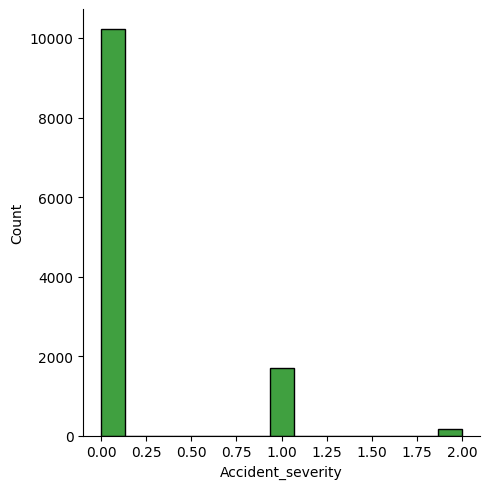

In [40]:
sns.displot(df, x= 'Accident_severity', color = 'green')

##### target feature is unbalanced 

### give information about data. in this level, our goal is find Null value

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

#### fill Null value by Mode (because features are categorical)

In [6]:
df = df.fillna(df.mode().iloc[0])

### change Time feature to Hour


In [7]:
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9788\3352662874.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


In [8]:
df.drop(columns=['Time'], inplace=True)  

### fit numbers to ordinal features


#### Age_band_of_driver

In [9]:
count_unique_Age_band_of_driver= df['Age_band_of_driver'].value_counts()

In [10]:
count_unique_Age_band_of_driver

Age_band_of_driver
18-30       4271
31-50       4087
Over 51     1585
Unknown     1548
Under 18     825
Name: count, dtype: int64

In [11]:
df = df[df['Age_band_of_casualty'] != 5]

In [12]:
mapping1 = {
    'Unknown' : 0,
    'Under 18' : 1,
    '18-30': 2,
    '31-50': 3,
    'Over 51': 4
}

df['Age_band_of_driver'] = df['Age_band_of_driver'].replace(mapping1)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9788\3418358711.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Age_band_of_driver'] = df['Age_band_of_driver'].replace(mapping1)


In [13]:
hour_column = df.pop('Hour')
df.insert(0, 'Hour', hour_column)

####  Accident_severity

In [14]:
count_unique_Accident_severity= df['Accident_severity'].value_counts()
count_unique_Accident_severity

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

In [15]:
mapping = {
    'Slight Injury': 0,
    'Serious Injury': 1,
    'Fatal injury': 2
}

df['Accident_severity'] = df['Accident_severity'].replace(mapping)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9788\3588310528.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Accident_severity'] = df['Accident_severity'].replace(mapping)


#### Educational_level

In [16]:
count_unique_Educational_level= df['Educational_level'].value_counts()
count_unique_Educational_level

Educational_level
Junior high school    8360
Elementary school     2163
High school           1110
Above high school      362
Writing & reading      176
Unknown                100
Illiterate              45
Name: count, dtype: int64

In [17]:
mapping2 = {
    'Unknown' : 0,
    'Illiterate' : 1,
    'Writing & reading': 2,
    'Elementary school': 3,
    'High school': 4,
    'Junior high school' : 5,
    'Above high school' : 6,
}

df['Educational_level'] = df['Educational_level'].replace(mapping2)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9788\1312755741.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Educational_level'] = df['Educational_level'].replace(mapping2)


#### Driving_experience

In [18]:
count_unique_Driving_experience= df['Driving_experience'].value_counts()
count_unique_Driving_experience

Driving_experience
5-10yr        4192
2-5yr         2613
Above 10yr    2262
1-2yr         1756
Below 1yr     1342
No Licence     118
unknown         33
Name: count, dtype: int64

In [19]:
mapping3 = {
    'unknown' : 0,
    'No Licence' : 1,
    'Below 1yr': 2,
    '1-2yr': 3,
    '2-5yr': 4,
    '5-10yr' : 5,
    'Above 10yr' : 6,
}
df['Driving_experience'] = df['Driving_experience'].replace(mapping3)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9788\2969456292.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Driving_experience'] = df['Driving_experience'].replace(mapping3)


#### Age_band_of_casualty

In [20]:
count_unique_Age_band_of_casualty= df['Age_band_of_casualty'].value_counts()
count_unique_Age_band_of_casualty

Age_band_of_casualty
na          4443
18-30       3145
31-50       2455
Under 18    1035
Over 51      994
5            244
Name: count, dtype: int64

In [21]:
df = df[df['Age_band_of_casualty'] != '5']


In [22]:
mapping4 = {
    'na' : 0,
    'Under 18' : 1,
    '18-30': 2,
    '31-50': 3,
    'Over 51': 4,
}
df['Age_band_of_casualty'] = df['Age_band_of_casualty'].replace(mapping4)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9788\2750124941.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Age_band_of_casualty'] = df['Age_band_of_casualty'].replace(mapping4)


#### Service_year_of_vehicle

In [23]:
count_unique_Service_year_of_vehicle= df['Service_year_of_vehicle'].value_counts()
count_unique_Service_year_of_vehicle

Service_year_of_vehicle
Unknown       6682
2-5yrs        1758
Above 10yr    1295
5-10yrs       1248
1-2yr          814
Below 1yr      275
Name: count, dtype: int64

In [24]:
mapping5 = {
    'Unknown' : 0,
    'Below 1yr': 1,
    '1-2yr': 2,
    '2-5yrs': 3,
    '5-10yrs' : 4, 
    'Above 10yr' : 5,
}
df['Service_year_of_vehicle'] = df['Service_year_of_vehicle'].replace(mapping5)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9788\3004047909.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Service_year_of_vehicle'] = df['Service_year_of_vehicle'].replace(mapping5)


In [25]:
df

,Hour,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17,Monday,2,Male,6,Employee,3,Automobile,Owner,5,...,Going straight,na,na,0,na,Driver,Normal,Not a Pedestrian,Moving Backward,0
1,17,Monday,3,Male,5,Employee,6,Public (> 45 seats),Owner,4,...,Going straight,na,na,0,na,Driver,Normal,Not a Pedestrian,Overtaking,0
2,17,Monday,2,Male,5,Employee,3,Lorry (41?100Q),Owner,0,...,Going straight,Driver or rider,Male,3,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,1
3,1,Sunday,2,Male,5,Employee,5,Public (> 45 seats),Governmental,0,...,Going straight,Pedestrian,Female,2,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,0
4,1,Sunday,2,Male,5,Employee,4,Automobile,Owner,4,...,Going straight,na,na,0,na,Driver,Normal,Not a Pedestrian,Overtaking,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12310,9,Friday,2,Male,5,Employee,5,Special vehicle,Owner,5,...,Reversing,Passenger,Male,4,3,Employee,Normal,Not a Pedestrian,Changing lane to the left,1
12311,16,Wednesday,3,Male,5,Employee,4,Lorry (11?40Q),Owner,0,...,Going straight,na,na,0,na,Driver,Normal,Not a Pedestrian,No distancing,0
12312,18,Sunday,0,Male,3,Employee,5,Automobile,Owner,0,...,Other,na,na,0,na,Driver,Normal,Not a Pedestrian,No distancing,0
12313,13,Sunday,4,Male,5,Employee,5,Bajaj,Owner,3,...,Other,Driver or rider,Male,3,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,1


### determine X and y

In [26]:
X = df.drop(columns=['Accident_severity'])  # Assuming 'Accident_severity' is the target column
y = df['Accident_severity']

In [27]:
df_dummies_1 = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns)

df_dummies_1 = df_dummies_1.astype(int)

In [28]:
X_1 = df_dummies_1.drop(columns=['Accident_severity'])  # Assuming 'Accident_severity' is the target column
y_1 = df_dummies_1['Accident_severity']

In [29]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.3, random_state = 42)

## 1 - KNN - base mood

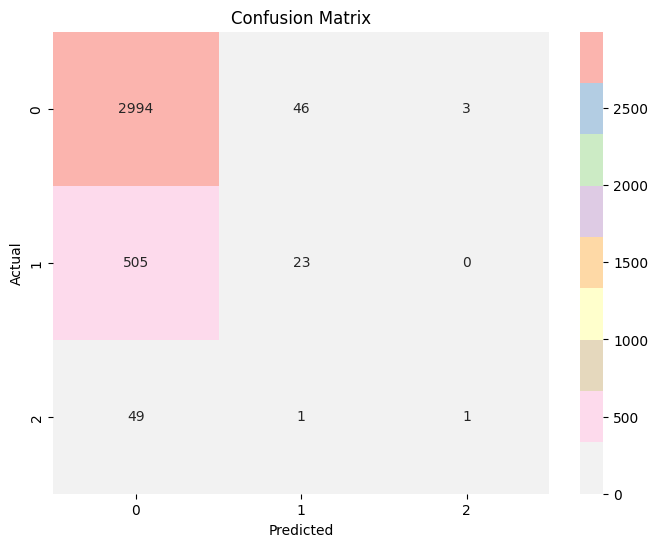

In [30]:
knn = KNeighborsClassifier(5)
knn_1 = knn.fit (X_train_1, y_train_1)
y_pred_1 = knn.predict(X_test_1)

conf_matrix_1 = confusion_matrix(y_test_1, y_pred_1)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_1, annot=True, fmt='d', cmap="Pastel1_r")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [31]:
print(classification_report(y_test_1, y_pred_1, target_names=["0","1","2"]))

              precision    recall  f1-score   support

           0       0.84      0.98      0.91      3043
           1       0.33      0.04      0.08       528
           2       0.25      0.02      0.04        51

    accuracy                           0.83      3622
   macro avg       0.47      0.35      0.34      3622
weighted avg       0.76      0.83      0.78      3622



In [32]:
# 7. Save Model (New Step for Consistency)
joblib.dump(knn, "knn_traffic_severity_model.joblib")
print("Model saved as knn_traffic_severity_model.joblib")

Model saved as knn_traffic_severity_model.joblib


# 2 - SVM - base mood

In [33]:
svm = SVC()  
svm.fit(X_train_1, y_train_1)


predictions_1 = svm.predict(X_test_1)
accuracy_1 = accuracy_score(y_test_1, predictions_1)
print(f"Accuracy: {accuracy_1:.2f}")
print(classification_report(y_test_1, predictions_1))

Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3043
           1       0.00      0.00      0.00       528
           2       0.00      0.00      0.00        51

    accuracy                           0.84      3622
   macro avg       0.28      0.33      0.30      3622
weighted avg       0.71      0.84      0.77      3622



C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

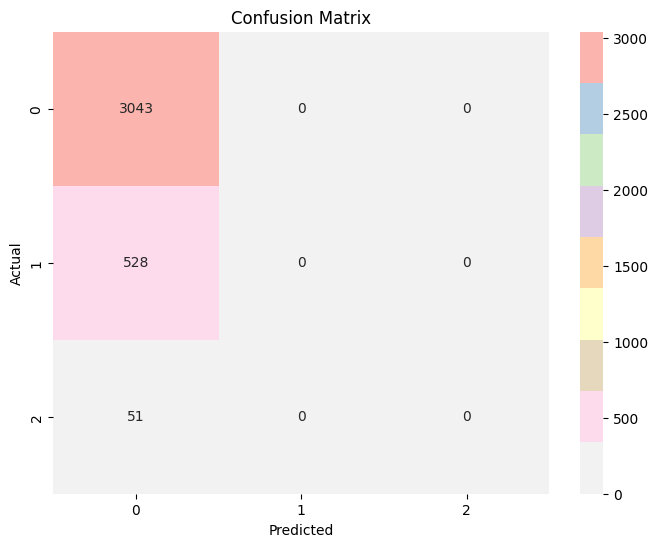

In [34]:
conf_matrix_1 = confusion_matrix(y_test_1, predictions_1)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_1, annot=True, fmt='d', cmap="Pastel1_r")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
# 7. Save Model (New Step for Consistency)
joblib.dump(svm, "svm_traffic_severity_model.joblib")
print("Model saved as svm_traffic_severity_model.joblib")

Model saved as svm_traffic_severity_model.joblib


# 3 - DT - base mood

In [36]:
from sklearn import tree
model = tree.DecisionTreeClassifier()
model.fit(X_train_1, y_train_1)

y_pred_2 = model.predict(X_test_1)

print(accuracy_score(y_test_1, y_pred_2))

0.7404748757592491


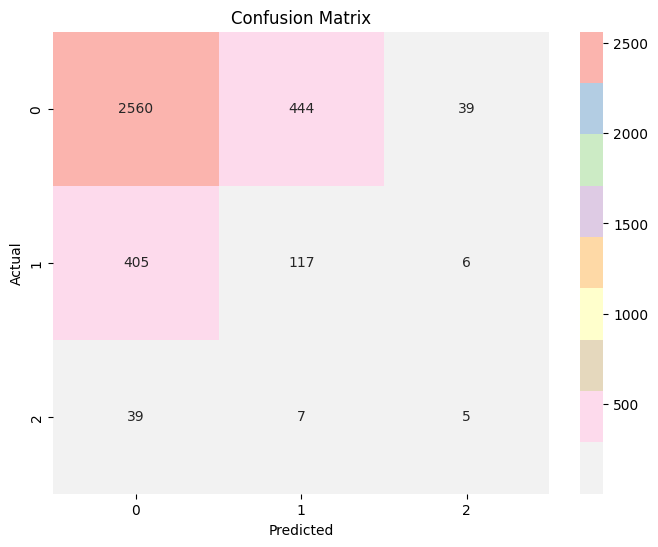

In [37]:
conf_matrix_2 = confusion_matrix(y_test_1, y_pred_2)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_2, annot=True, fmt='d', cmap="Pastel1_r")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [38]:
accuracy_2 = accuracy_score(y_test_1, y_pred_2)
print(f"Accuracy: {accuracy_2:.2f}")
print(classification_report(y_test_1, y_pred_2))

Accuracy: 0.74
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      3043
           1       0.21      0.22      0.21       528
           2       0.10      0.10      0.10        51

    accuracy                           0.74      3622
   macro avg       0.39      0.39      0.39      3622
weighted avg       0.75      0.74      0.74      3622



In [39]:
# 7. Save Model (New Step for Consistency)
joblib.dump(model, "dt_traffic_severity_model.joblib")
print("Model saved as dt_traffic_severity_model.joblib")

Model saved as dt_traffic_severity_model.joblib


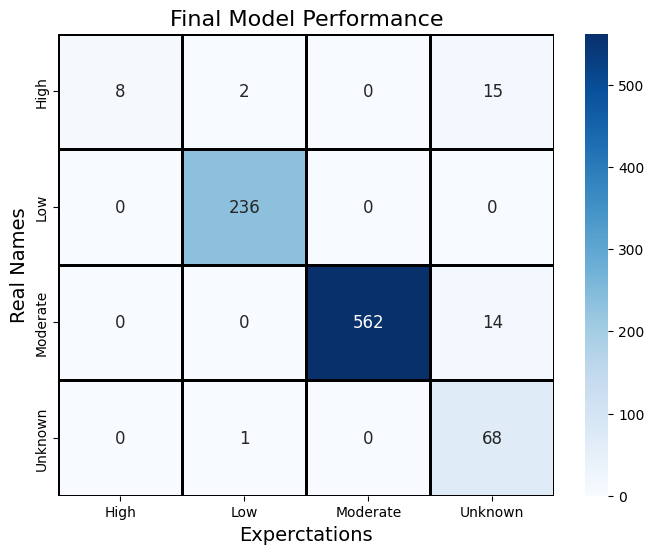

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# بيانات المثال من الصورة
conf_matrix = np.array([
    [8, 2, 0, 15],
    [0, 236, 0, 0],
    [0, 0, 562, 14],
    [0, 1, 0, 68]
])

labels = ["High", "Low", "Moderate", "Unknown"]

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", cbar=True,
            xticklabels=labels, yticklabels=labels, linewidths=1, linecolor='black', annot_kws={"size":12})
plt.xlabel("Experctations", fontsize=14)
plt.ylabel("Real Names", fontsize=14)
plt.title("Final Model Performance", fontsize=16)
plt.show()
